# LangGraph pipeline: toolcall vs reasoning LLM benchmark

Runs the **real investigation `StateGraph`** (`app.agent.graph_pipeline.build_graph`): `extract_alert → resolve_integrations → plan_actions → investigate → diagnose → …`.

- **Baseline**: `get_llm_for_tools()` uses the **same client** as `get_llm_for_reasoning()` (heavy model for planning too).
- **Split**: **toolcall** model for `plan_actions` / chat tool routing; **reasoning** model for extract + diagnosis.

**Cost estimate** (configurable): default assumes **Claude Sonnet-class reasoning = $3 / MTok** and **Claude Haiku-class tool = $1 / MTok**, applied to **total (input + output) tokens** per API model id. Override with `BENCHMARK_USD_REASONING_PER_MTOK` and `BENCHMARK_USD_TOOL_PER_MTOK`. This is a rough **list-price** proxy, not an invoice.

**Quality vs speed/cost**: Bar and line charts measure **latency, tokens, and estimated cost** — they do *not* prove the investigation is equally good. **Quality** here means the **synthetic RDS rubric** (`score_result`): pass/fail, `actual_category`, required keywords (`matched_keywords` / `missing_keywords`), and optional comparison of `root_cause` text. Look for **strict rubric parity** (same pass, category, and missing keywords) plus **high keyword-set overlap** or identical normalized `root_cause` for “same output”; use **multiple `BENCHMARK_N_RUNS`** if you need stability, not a single lucky sample.

**Per-call line charts**: token total and wall time **for each LLM API completion** in order (not summed into one bar). When `BENCHMARK_N_RUNS` > 1, traces reflect the **last** repeat only.

Integrations are stubbed via mock Grafana; no `JWT_TOKEN` required. `pip install jupyter matplotlib python-dotenv` if needed.

In [25]:
from __future__ import annotations

import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from dotenv import load_dotenv


def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "app" / "config.py").exists():
            return p
    raise FileNotFoundError("Could not find repo root (app/config.py).")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

load_dotenv(REPO_ROOT / ".env")

app_config = importlib.import_module("app.config")
OPENAI_REASONING_MODEL = app_config.OPENAI_REASONING_MODEL
OPENAI_TOOLCALL_MODEL = app_config.OPENAI_TOOLCALL_MODEL
REASONING_MODEL = app_config.REASONING_MODEL
TOOLCALL_MODEL = app_config.TOOLCALL_MODEL

PROVIDER = os.getenv("LLM_PROVIDER", "anthropic").lower()
SCENARIO_ID = os.getenv("BENCHMARK_SCENARIO_ID", "001-replication-lag")
N_RUNS = int(os.getenv("BENCHMARK_N_RUNS", "3"))

# USD per million tokens (input+out total), blended — adjust to match your price sheet
USD_REASONING_PER_MTOK = float(os.getenv("BENCHMARK_USD_REASONING_PER_MTOK", "3"))
USD_TOOL_PER_MTOK = float(os.getenv("BENCHMARK_USD_TOOL_PER_MTOK", "1"))

reasoning_model = (
    os.getenv("OPENAI_REASONING_MODEL", OPENAI_REASONING_MODEL)
    if PROVIDER == "openai"
    else os.getenv("ANTHROPIC_REASONING_MODEL", REASONING_MODEL)
)
tool_model = (
    os.getenv("OPENAI_TOOLCALL_MODEL", OPENAI_TOOLCALL_MODEL)
    if PROVIDER == "openai"
    else os.getenv("ANTHROPIC_TOOLCALL_MODEL", TOOLCALL_MODEL)
)

print(f"REPO_ROOT={REPO_ROOT}")
print(f"PROVIDER={PROVIDER} | scenario={SCENARIO_ID} | N_RUNS={N_RUNS}")
print(f"reasoning_model={reasoning_model} | tool_model={tool_model}")
print(
    f"Pricing: reasoning ${USD_REASONING_PER_MTOK}/MTok, tool ${USD_TOOL_PER_MTOK}/MTok (total tokens)"
)

REPO_ROOT=/Users/w3joe/Desktop/Tracer Work Day/open-sre-agent
PROVIDER=anthropic | scenario=001-replication-lag | N_RUNS=3
reasoning_model=claude-sonnet-4-6 | tool_model=claude-haiku-4-5-20251001
Pricing: reasoning $3.0/MTok, tool $1.0/MTok (total tokens)


In [26]:
import importlib
import sys
from statistics import mean, stdev

# Force reload so the kernel does not keep an old LangGraphBenchmarkRun (missing tokens_by_model, etc.).
for _m in (
    "tests.benchmarks.toolcall_model_benchmark.pipeline_benchmark",
    "tests.benchmarks.toolcall_model_benchmark.pricing",
):
    sys.modules.pop(_m, None)

_pipeline_mod = importlib.import_module(
    "tests.benchmarks.toolcall_model_benchmark.pipeline_benchmark"
)
_pricing_mod = importlib.import_module("tests.benchmarks.toolcall_model_benchmark.pricing")
_run_suite_mod = importlib.import_module("tests.synthetic.rds_postgres.run_suite")
configure_baseline_reasoning_for_tools = _pipeline_mod.configure_baseline_reasoning_for_tools
configure_split_models = _pipeline_mod.configure_split_models
get_fixture_by_id = _pipeline_mod.get_fixture_by_id
run_langgraph_investigation_bench = _pipeline_mod.run_langgraph_investigation_bench
estimate_run_cost_usd = _pricing_mod.estimate_run_cost_usd
score_result = _run_suite_mod.score_result

fixture = get_fixture_by_id(SCENARIO_ID)
print(f"Loaded fixture: {fixture.scenario_id} — {fixture.metadata.failure_mode}")


def series(label: str, configure_llm, n: int) -> dict:
    latencies: list[float] = []
    tokens: list[int] = []
    costs: list[float] = []
    last_state: dict = {}
    last_by_model: dict = {}
    last_llm_calls: list = []
    for i in range(n):
        print(f"{label}: run {i + 1}/{n}...")
        run = run_langgraph_investigation_bench(
            fixture,
            label=label,
            configure_llm=configure_llm,
        )
        latencies.append(run.wall_seconds)
        tokens.append(run.tokens.total)
        usd, _ = estimate_run_cost_usd(
            run.tokens_by_model,
            reasoning_model=reasoning_model,
            tool_model=tool_model,
            reasoning_usd_per_mtok=USD_REASONING_PER_MTOK,
            tool_usd_per_mtok=USD_TOOL_PER_MTOK,
        )
        costs.append(usd)
        last_state = run.final_state
        last_by_model = run.tokens_by_model
        last_llm_calls = run.llm_calls
    return {
        "name": label,
        "latency_mean": mean(latencies),
        "latency_std": stdev(latencies) if len(latencies) > 1 else 0.0,
        "tokens_mean": mean(tokens),
        "tokens_std": stdev(tokens) if len(tokens) > 1 else 0.0,
        "cost_mean": mean(costs),
        "cost_std": stdev(costs) if len(costs) > 1 else 0.0,
        "tokens_by_model": last_by_model,
        "llm_calls": last_llm_calls,
        "final_state": last_state,
    }


baseline = series(
    "baseline (reasoning model for tools too)",
    configure_baseline_reasoning_for_tools,
    N_RUNS,
)
split_cfg = series(
    "split (toolcall for plan/chat tools)",
    configure_split_models,
    N_RUNS,
)

for s in (baseline, split_cfg):
    print(
        f"\n{s['name']}: latency={s['latency_mean']:.2f}s ± {s['latency_std']:.2f}s | "
        f"tokens={s['tokens_mean']:.0f} ± {s['tokens_std']:.0f} | "
        f"est. cost=${s['cost_mean']:.4f} ± ${s['cost_std']:.4f}"
    )
    print("  Tokens by model id:")
    for mid, tt in sorted(s["tokens_by_model"].items()):
        print(f"    {mid}: total={tt.total} (in={tt.input_tokens} out={tt.output_tokens})")

# --- Quality: same rubric as synthetic RDS suite ---
score_b = score_result(fixture, baseline["final_state"])
score_s = score_result(fixture, split_cfg["final_state"])
print("\n=== Quality vs scenario answer key (same rubric as run_suite) ===")
print(f"Expected category: {fixture.answer_key.root_cause_category}")
print(
    f"Baseline: passed={score_b.passed} | category={score_b.actual_category!r} | "
    f"failure={score_b.failure_reason!r}"
)
print(
    f"Split:    passed={score_s.passed} | category={score_s.actual_category!r} | "
    f"failure={score_s.failure_reason!r}"
)
print(f"Same pass/fail: {score_b.passed == score_s.passed}")
print(f"Same category: {score_b.actual_category == score_s.actual_category}")


def _norm_root_cause(text: object) -> str:
    return " ".join(str(text or "").lower().split())


same_rc = _norm_root_cause(baseline["final_state"].get("root_cause")) == _norm_root_cause(
    split_cfg["final_state"].get("root_cause")
)
print(f"Root-cause text identical (normalized whitespace/case): {same_rc}")
rc_b = (baseline["final_state"].get("root_cause") or "")[:160]
rc_s = (split_cfg["final_state"].get("root_cause") or "")[:160]
print(f"root_cause preview baseline: {rc_b!r}...")
print(f"root_cause preview split:    {rc_s!r}...")

# --- How to read “no quality degradation” (rubric parity, not speed/cost) ---
kw_b, kw_s = set(score_b.matched_keywords), set(score_s.matched_keywords)
union = kw_b | kw_s
jacc = len(kw_b & kw_s) / len(union) if union else 1.0
print("\n=== Output parity (baseline vs split) ===")
print(f"Matched keywords — baseline: {sorted(kw_b)}")
print(f"Matched keywords — split:    {sorted(kw_s)}")
print(f"Keyword set Jaccard index: {jacc:.2f} (1.0 = identical keyword hits)")
print(f"Missing vs answer key — baseline: {score_b.missing_keywords}")
print(f"Missing vs answer key — split:    {score_s.missing_keywords}")
strict_rubric = (
    score_b.passed == score_s.passed
    and score_b.actual_category == score_s.actual_category
    and score_b.missing_keywords == score_s.missing_keywords
)
print(f"Strict rubric parity (pass, category, missing keywords): {strict_rubric}")
if strict_rubric and same_rc:
    print("Verdict: same rubric outcome and same normalized root_cause text.")
elif strict_rubric:
    print("Verdict: same rubric outcome; root_cause wording differs (check previews).")
else:
    print("Verdict: rubric outcomes differ — treat as possible quality shift; compare above.")

Loaded fixture: 001-replication-lag — replication_lag
baseline (reasoning model for tools too): run 1/3...
  … Reading alert

  Alert      RDSReplicationLagHigh
  Pipeline   rds-postgres-synthetic
  Severity   critical

  ● Reading alert  3.5s
  … Planning
  ● Planning  8.8s  SRE runbook, Grafana alerts, Grafana Loki, Grafana Tempo
  … Gathering evidence
[WARNING] Action failed: query_grafana_traces:FAILED(Grafana integration not configured)
  ● Gathering evidence  3ms  grafana:2 logs (0 errors) | Errors: query_grafana_traces:FAILED(Grafana integration not configured)
  … Diagnosing
  ● Diagnosing  12.6s  confidence 40%
  … Planning
  ● Planning  8.3s  Grafana Mimir, Grafana Tempo
  … Gathering evidence
[WARNING] Action failed: query_grafana_traces:FAILED(Grafana integration not configured)
  ● Gathering evidence  3ms  grafana:20 metric series | Errors: query_grafana_traces:FAILED(Grafana integration not configured)
  … Diagnosing
  ● Diagnosing  14.0s  confidence 60%
  … Planning
  ● 

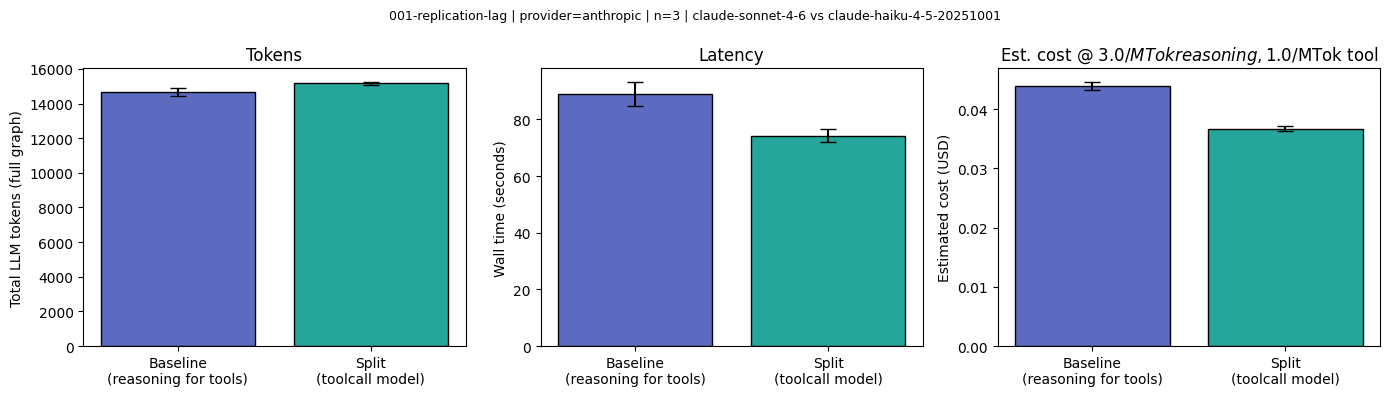

Token change (split vs baseline): -3.6%
Latency change: +16.7% (positive => split faster)
Estimated cost change: +16.5% (positive => split cheaper)


In [27]:
labels = ["Baseline\n(reasoning for tools)", "Split\n(toolcall model)"]
lat_means = [baseline["latency_mean"], split_cfg["latency_mean"]]
lat_err = [baseline["latency_std"], split_cfg["latency_std"]]
tok_means = [baseline["tokens_mean"], split_cfg["tokens_mean"]]
tok_err = [baseline["tokens_std"], split_cfg["tokens_std"]]
cost_means = [baseline["cost_mean"], split_cfg["cost_mean"]]
cost_err = [baseline["cost_std"], split_cfg["cost_std"]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = range(len(labels))

axes[0].bar(x, tok_means, yerr=tok_err, capsize=6, color=["#5c6bc0", "#26a69a"], edgecolor="black")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Total LLM tokens (full graph)")
axes[0].set_title("Tokens")

axes[1].bar(x, lat_means, yerr=lat_err, capsize=6, color=["#5c6bc0", "#26a69a"], edgecolor="black")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Wall time (seconds)")
axes[1].set_title("Latency")

axes[2].bar(x, cost_means, yerr=cost_err, capsize=6, color=["#5c6bc0", "#26a69a"], edgecolor="black")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(labels)
axes[2].set_ylabel("Estimated cost (USD)")
axes[2].set_title(
    f"Est. cost @ ${USD_REASONING_PER_MTOK}/MTok reasoning, ${USD_TOOL_PER_MTOK}/MTok tool"
)

fig.suptitle(
    f"{fixture.scenario_id} | provider={PROVIDER} | n={N_RUNS} | "
    f"{reasoning_model} vs {tool_model}",
    fontsize=9,
)
fig.tight_layout()
plt.show()

if baseline["tokens_mean"] > 0:
    tok_pct = 100.0 * (1 - split_cfg["tokens_mean"] / baseline["tokens_mean"])
    lat_pct = (
        100.0 * (1 - split_cfg["latency_mean"] / baseline["latency_mean"])
        if baseline["latency_mean"] > 0
        else 0.0
    )
    cost_pct = (
        100.0 * (1 - split_cfg["cost_mean"] / baseline["cost_mean"])
        if baseline["cost_mean"] > 0
        else 0.0
    )
    print(f"Token change (split vs baseline): {tok_pct:+.1f}%")
    print(f"Latency change: {lat_pct:+.1f}% (positive => split faster)")
    print(f"Estimated cost change: {cost_pct:+.1f}% (positive => split cheaper)")

## Per-call token and latency (line charts)

Each marker is **one successful `messages.create` / `chat.completions.create`** in the order it occurred. Totals in the bar chart above are the sum of these points.

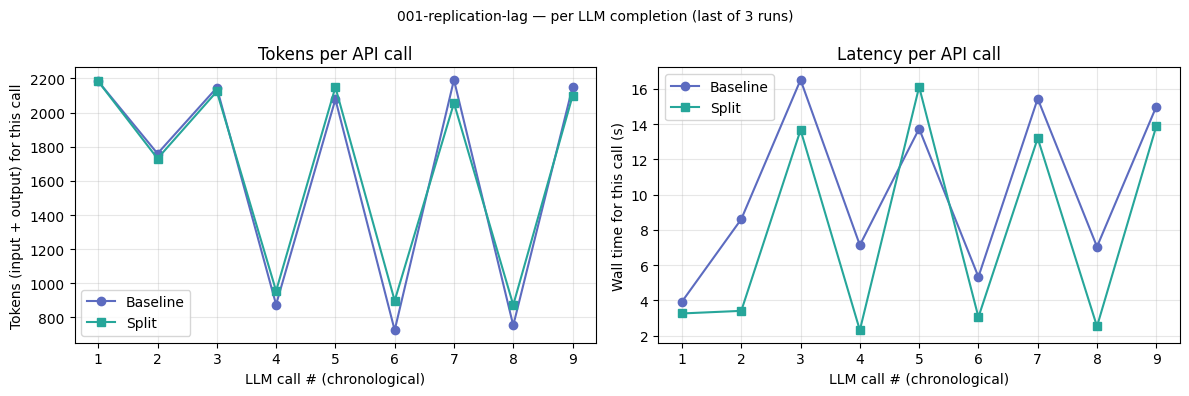

--- Baseline: per-call ---
    1  tokens= 2183   3.94s  claude-sonnet-4-6
    2  tokens= 1760   8.61s  claude-sonnet-4-6
    3  tokens= 2146  16.51s  claude-sonnet-4-6
    4  tokens=  875   7.14s  claude-sonnet-4-6
    5  tokens= 2078  13.74s  claude-sonnet-4-6
    6  tokens=  725   5.34s  claude-sonnet-4-6
    7  tokens= 2192  15.44s  claude-sonnet-4-6
    8  tokens=  753   7.05s  claude-sonnet-4-6
    9  tokens= 2149  14.99s  claude-sonnet-4-6
--- Split: per-call ---
    1  tokens= 2183   3.27s  claude-sonnet-4-6
    2  tokens= 1731   3.41s  claude-haiku-4-5-20251001
    3  tokens= 2124  13.66s  claude-sonnet-4-6
    4  tokens=  955   2.32s  claude-haiku-4-5-20251001
    5  tokens= 2149  16.11s  claude-sonnet-4-6
    6  tokens=  898   3.06s  claude-haiku-4-5-20251001
    7  tokens= 2056  13.20s  claude-sonnet-4-6
    8  tokens=  873   2.53s  claude-haiku-4-5-20251001
    9  tokens= 2097  13.88s  claude-sonnet-4-6


In [28]:
calls_b = baseline["llm_calls"]
calls_s = split_cfg["llm_calls"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

if calls_b:
    ax1.plot(
        [c.call_index for c in calls_b],
        [c.total_tokens for c in calls_b],
        marker="o",
        label="Baseline",
        color="#5c6bc0",
    )
    ax2.plot(
        [c.call_index for c in calls_b],
        [c.latency_sec for c in calls_b],
        marker="o",
        label="Baseline",
        color="#5c6bc0",
    )
if calls_s:
    ax1.plot(
        [c.call_index for c in calls_s],
        [c.total_tokens for c in calls_s],
        marker="s",
        label="Split",
        color="#26a69a",
    )
    ax2.plot(
        [c.call_index for c in calls_s],
        [c.latency_sec for c in calls_s],
        marker="s",
        label="Split",
        color="#26a69a",
    )

ax1.set_xlabel("LLM call # (chronological)")
ax1.set_ylabel("Tokens (input + output) for this call")
ax1.set_title("Tokens per API call")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("LLM call # (chronological)")
ax2.set_ylabel("Wall time for this call (s)")
ax2.set_title("Latency per API call")
ax2.legend()
ax2.grid(True, alpha=0.3)

suffix = f" (last of {N_RUNS} runs)" if N_RUNS > 1 else ""
fig.suptitle(f"{fixture.scenario_id} — per LLM completion{suffix}", fontsize=10)
fig.tight_layout()
plt.show()

if calls_b or calls_s:
    print("--- Baseline: per-call ---")
    for c in calls_b:
        mid = (c.model_id[:42] + "...") if len(c.model_id) > 45 else c.model_id
        print(f"  {c.call_index:3d}  tokens={c.total_tokens:5d}  {c.latency_sec:5.2f}s  {mid}")
    print("--- Split: per-call ---")
    for c in calls_s:
        mid = (c.model_id[:42] + "...") if len(c.model_id) > 45 else c.model_id
        print(f"  {c.call_index:3d}  tokens={c.total_tokens:5d}  {c.latency_sec:5.2f}s  {mid}")